In [18]:
!rm *.svg

# Offloading Adaptativo para Redes Neurais com Saídas Antecipadas: Equilíbrio e Compartilhamento de Recursos através de Multi-Armed Bandits
#### _Kit de Reprodução de Experimentos_

**Enviado para o Simpósio Brasileiro de Redes de Computadores (SBRC 2026)**

## Definição dos Agentes

Os agentes são definidos com base no algoritmo **UCB** (Upper Confidence Bound) e respeitam o seguinte pseudocódigo:

---

### **Algoritmo 1:** Seleção de Limiar de Confiança (UCB)

* **Entradas:** $K$ (número de limiares), parâmetro de exploração $\tilde{c} > 0$.
* **Inicialização:** Para todo braço $k$, define-se $Q_k \leftarrow 0$ e $N_k \leftarrow 0$.

**Para cada passo de tempo $t = 1, \dots, T$:**

1.  **Chegada da Amostra:**
    O agente recebe a amostra atual $\boldsymbol{x}_t$.

2.  **Seleção do Limiar ($\alpha_t$):**
    Calcula-se o índice UCB para cada braço e seleciona-se o maior:
    $$\alpha_t \leftarrow \underset{k}{\text{argmax}} \left( Q_k + \tilde{c} \cdot \sqrt{\frac{2 \ln t}{N_k}} \right)$$

3.  **Decisão de Processamento:**
    * **Se** $C_I(\boldsymbol{x}_t) \ge \alpha_t$:
        * **Ação:** Processar Localmente.
        * **Recompensa:** $r_t \leftarrow 0.0$.
    * **Senão** (caso contrário):
        * **Ação:** Realizar *Offloading* para a Nuvem.
        * **Recompensa:** $r_t \leftarrow C_L(\boldsymbol{x}\_t) - \eta_{i,t}(o\_{i, t})$ em caso de offloading bem sucedido e $- \eta_{i,t}(o\_{i, t})$ caso contrário.

4.  **Atualização das Estimativas:**
    Atualiza-se a média do braço escolhido (fórmula incremental):
    $$N_{\alpha_t} \leftarrow N_{\alpha_t} + 1$$
    $$Q_{\alpha_t} \leftarrow Q_{\alpha_t} + \frac{1}{N_{\alpha_t}}(r_t - Q_{\alpha_t})$$

---

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta

In [20]:
# parametros de agente e Ambiente
N_ACOES = 100
LIMIARES = np.linspace(0.0, 1.0, N_ACOES)
CUSTO_FIXO = 0.05                           # custo base da tentativa de offloading
CUSTO_MAX_PENALTY = 1.0

class UCBAgent:

    def __init__(self, energia_inicial):

        self.counts = np.zeros(N_ACOES) # numero de vezes em que um braço é escolhido
        self.values = np.zeros(N_ACOES) # média de recompensas por braço
        self.total_n = 0                # número de braços
        self.e0 = energia_inicial       # energia inicial
        self.e = energia_inicial        # energia restante

    def select_action(self):
        self.total_n += 1
        if 0 in self.counts: return np.argmin(self.counts)

        # calcular a cota superior
        confidence = np.sqrt((2 * np.log(self.total_n)) / (self.counts + 1e-7))
        return np.argmax(self.values + confidence)

    def update(self, idx, reward, consumiu):
        if consumiu and self.e > 0: self.e -= 1.0
        self.counts[idx] += 1
        n = self.counts[idx]
        self.values[idx] += (reward - self.values[idx]) / n

def calc_reward(agente, intent, success, ci, cl):

    # se não tem intenção de offloading, processa local (ci)
    if not intent: return 0.0

    # incorporando escassez de recursos à função de custo de offloading
    consumption_bonus = (agente.e0 - agente.e) / agente.e0


    return (cl + consumption_bonus) if success else consumption_bonus

def smooth(x, w): # para médias móveis nas visualizações
    return np.convolve(x, np.ones(w)/w, 'valid')

## Setup do Jogo Estocástico

In [21]:
N_EPISODIOS = 40
T_TURNOS = 1500
WINDOW_SMOOTH = 60


BETA_CI = (8, 4)    # média = 0.667  | confiança moderada na borda
BETA_CL = (12, 3)   # média = 0.800  | vantagem clara da nuvem

BAT_100 = 500.0
BAT_30  = 150.0
PROB_70 = 0.7
PROB_30 = 0.3


In [22]:
def visualizar_distribuicoes(ci_params, cl_params):

    x = np.linspace(0, 1, 1000)

    # Desempacota parâmetros
    a_ci, b_ci = ci_params
    a_cl, b_cl = cl_params

    # Cria os objetos de distribuição
    rv_ci = beta(a_ci, b_ci)
    rv_cl = beta(a_cl, b_cl)

    # Calcula as médias teóricas
    mean_ci = rv_ci.mean()
    mean_cl = rv_cl.mean()

    plt.figure(figsize=(10, 6))

    # plotagem
    y_ci = rv_ci.pdf(x)
    plt.plot(x, y_ci, color='#7f7f7f', lw=2.5, label=f'Processamento Local (CI)\nBeta({a_ci}, {b_ci}) | Média: {mean_ci:.2f}')
    plt.fill_between(x, y_ci, color='#7f7f7f', alpha=0.2)
    plt.axvline(mean_ci, color='#7f7f7f', linestyle='--', alpha=0.8)
    y_cl = rv_cl.pdf(x)
    plt.plot(x, y_cl, color='#2ca02c', lw=2.5, label=f'Nuvem (CL)\nBeta({a_cl}, {b_cl}) | Média: {mean_cl:.2f}')
    plt.fill_between(x, y_cl, color='#2ca02c', alpha=0.2)
    plt.axvline(mean_cl, color='#2ca02c', linestyle='--', alpha=0.8)


    plt.xlabel('Qualidade de Serviço / Recompensa (0.0 a 1.0)', fontsize=12)
    plt.ylabel('Densidade de Probabilidade', fontsize=12)
    plt.legend(fontsize=11, loc='upper left', frameon=True, fancybox=False, edgecolor='#cccccc')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xlim(0, 1.0)
    plt.ylim(bottom=0)

    # Anotação de Gap
    gap = mean_cl - mean_ci
    plt.annotate(f'Gap Médio: +{gap:.2f}',
                 xy=((mean_ci + mean_cl)/2, max(y_ci.max(), y_cl.max())*0.8),
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

    plt.tight_layout()
    plt.show()

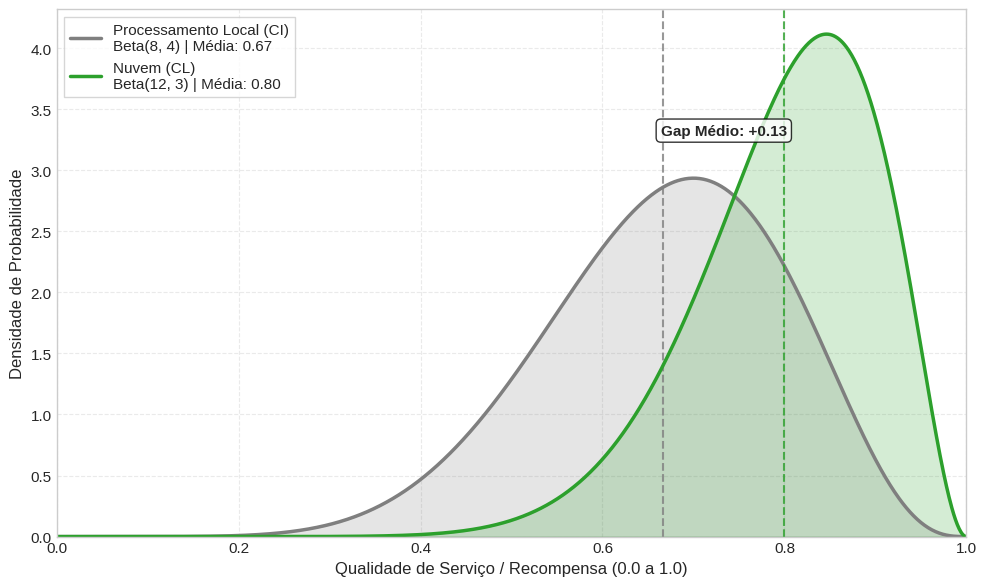

In [23]:
visualizar_distribuicoes(BETA_CI, BETA_CL)

## Simulação e Visualização

In [24]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2

# Cores dos dispositivos
COR_D1 = '#1f77b4'  # Azul
COR_D2 = '#d62728'  # Vermelho

In [25]:
def rodar_cenario(nome_arquivo_base, titulo_texto, d1_params, d2_params):
    print(f"Iniciando cenário: {titulo_texto if titulo_texto else nome_arquivo_base}...")

    h_alpha1 = np.zeros((N_EPISODIOS, T_TURNOS))
    h_alpha2 = np.zeros((N_EPISODIOS, T_TURNOS))
    h_reward1 = np.zeros((N_EPISODIOS, T_TURNOS))
    h_reward2 = np.zeros((N_EPISODIOS, T_TURNOS))

    counts_total1 = np.zeros(len(LIMIARES))
    counts_total2 = np.zeros(len(LIMIARES))

    e_d1_init, p_d1 = d1_params
    e_d2_init, p_d2 = d2_params

    for j in range(N_EPISODIOS):
        d1 = UCBAgent(e_d1_init)
        d2 = UCBAgent(e_d2_init)

        for t in range(T_TURNOS):
            ci1, cl1 = np.random.beta(*BETA_CI), np.random.beta(*BETA_CL)
            ci2, cl2 = np.random.beta(*BETA_CI), np.random.beta(*BETA_CL)

            idx1, idx2 = d1.select_action(), d2.select_action()
            a1, a2 = LIMIARES[idx1], LIMIARES[idx2]

            int1 = (ci1 < a1) and (d1.e > 0)
            int2 = (ci2 < a2) and (d2.e > 0)

            suc1, suc2 = False, False

            if int1 and int2:
                if np.random.rand() < p_d1: suc1 = True
                else: suc2 = True
            elif int1: suc1 = True
            elif int2: suc2 = True

            r1 = calc_reward(d1, int1, suc1, ci1, cl1)
            r2 = calc_reward(d2, int2, suc2, ci2, cl2)

            d1.update(idx1, r1, int1)
            d2.update(idx2, r2, int2)

            h_alpha1[j, t] = a1
            h_alpha2[j, t] = a2
            h_reward1[j, t] = r1
            h_reward2[j, t] = r2

            if t > 20:
                counts_total1[idx1] += 1
                counts_total2[idx2] += 1

    s_a1 = smooth(np.mean(h_alpha1, axis=0), WINDOW_SMOOTH)
    s_a2 = smooth(np.mean(h_alpha2, axis=0), WINDOW_SMOOTH)

    s_r1 = smooth(np.mean(h_reward1, axis=0), WINDOW_SMOOTH)
    s_r2 = smooth(np.mean(h_reward2, axis=0), WINDOW_SMOOTH)

    x_axis = np.arange(WINDOW_SMOOTH - 1, T_TURNOS)


    l1 = f'D1 ($\\eta_{{1,\\max}}={e_d1_init:.0f}$, $P_{{suc}}={p_d1*100:.0f}\\%$)'
    l2 = f'D2 ($\\eta_{{2,\\max}}={e_d2_init:.0f}$, $P_{{suc}}={p_d2*100:.0f}\\%$)'

    base_name = nome_arquivo_base.replace('.svg', '')

    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, s_a1, label=l1, color=COR_D1, linewidth=2)
    plt.plot(x_axis, s_a2, label=l2, color=COR_D2, linewidth=2)

    plt.axhspan(0.75, 1.0, color='green', alpha=0.07, label='Zona Nuvem')
    plt.axhspan(0.0, 0.25, color='gray', alpha=0.1, label='Zona Borda')


    plt.ylabel(r'Limiar ($\alpha$)', fontsize=11)
    plt.xlabel('Turnos', fontsize=11)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{base_name}_alpha.svg", bbox_inches='tight')
    plt.show()
    plt.close()

    # recompensa média
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, s_r1, label=l1, color=COR_D1, linewidth=2)
    plt.plot(x_axis, s_r2, label=l2, color=COR_D2, linewidth=2)

    plt.ylabel(r'Recompensa Média ($r_t$)', fontsize=11)
    plt.xlabel('Turnos', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{base_name}_reward.svg", bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Salvos: {base_name}_alpha.svg, {base_name}_reward.svg, {base_name}_hist.svg")

In [26]:
def rodar_analise_bateria(nome_arquivo, d1_base_params, d2_base_params):
    print(f"Gerando análise de sensibilidade com barras de erro: {nome_arquivo}...")

    factors = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
    labels_x = [f'{f}x' for f in factors]

    # Listas para armazenar as médias e os desvios
    final_means_d1, final_stds_d1 = [], []
    final_means_d2, final_stds_d2 = [], []

    base_e1, p1 = d1_base_params
    base_e2, p2 = d2_base_params

    for f in factors:
        curr_e1 = base_e1 * f
        curr_e2 = base_e2 * f

        # Armazena a recompensa média de CADA episódio para calcular estatísticas
        rewards_episodios_d1 = []
        rewards_episodios_d2 = []

        for _ in range(N_EPISODIOS):
            d1 = UCBAgent(curr_e1)
            d2 = UCBAgent(curr_e2)
            ep_reward1, ep_reward2 = 0, 0

            for t in range(T_TURNOS):
                ci1, cl1 = np.random.beta(*BETA_CI), np.random.beta(*BETA_CL)
                ci2, cl2 = np.random.beta(*BETA_CI), np.random.beta(*BETA_CL)

                idx1, idx2 = d1.select_action(), d2.select_action()
                a1, a2 = LIMIARES[idx1], LIMIARES[idx2]

                int1 = (ci1 < a1) and (d1.e > 0)
                int2 = (ci2 < a2) and (d2.e > 0)

                suc1, suc2 = False, False
                if int1 and int2:
                    if np.random.rand() < p1: suc1, suc2 = True, False
                    else: suc1, suc2 = False, True
                elif int1: suc1 = True
                elif int2: suc2 = True

                r1 = calc_reward(d1, int1, suc1, ci1, cl1)
                r2 = calc_reward(d2, int2, suc2, ci2, cl2)

                d1.update(idx1, r1, int1)
                d2.update(idx2, r2, int2)
                ep_reward1 += r1
                ep_reward2 += r2

            rewards_episodios_d1.append(ep_reward1 / T_TURNOS)
            rewards_episodios_d2.append(ep_reward2 / T_TURNOS)

        # Estatísticas finais para o fator atual
        final_means_d1.append(np.mean(rewards_episodios_d1))
        final_stds_d1.append(np.std(rewards_episodios_d1))

        final_means_d2.append(np.mean(rewards_episodios_d2))
        final_stds_d2.append(np.std(rewards_episodios_d2))

    # PLOTAGEM
    plt.figure(figsize=(9, 6))
    x = np.arange(len(factors))
    width = 0.35

    error_config = dict(ecolor='black', lw=1, capsize=4, alpha=0.7)

    # Barras com desvio padrão
    plt.bar(x - width/2, final_means_d1, width, yerr=final_stds_d1, error_kw=error_config,
            label='Agente D1', color=COR_D1, alpha=0.9, edgecolor='black')

    plt.bar(x + width/2, final_means_d2, width, yerr=final_stds_d2, error_kw=error_config,
            label='Agente D2', color=COR_D2, alpha=0.9, edgecolor='black')

    plt.xlabel('Fator Multiplicador de Bateria (vs Base)', fontsize=11)
    plt.ylabel('Recompensa Média Acumulada', fontsize=11)
    plt.xticks(x, labels_x, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(frameon=True, loc='upper left')

    plt.tight_layout()
    plt.savefig(nome_arquivo, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Gráfico salvo com sucesso: {nome_arquivo}")

## Especificações de Simulação

Iniciando cenário: cenario1_dominancia.svg...


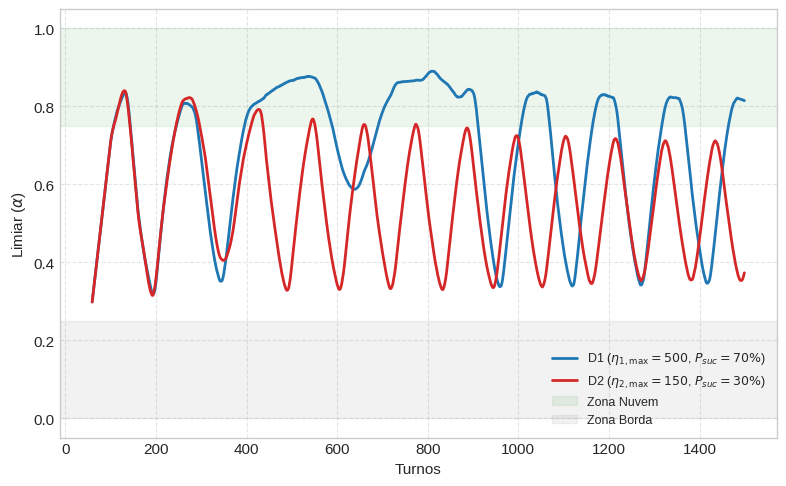

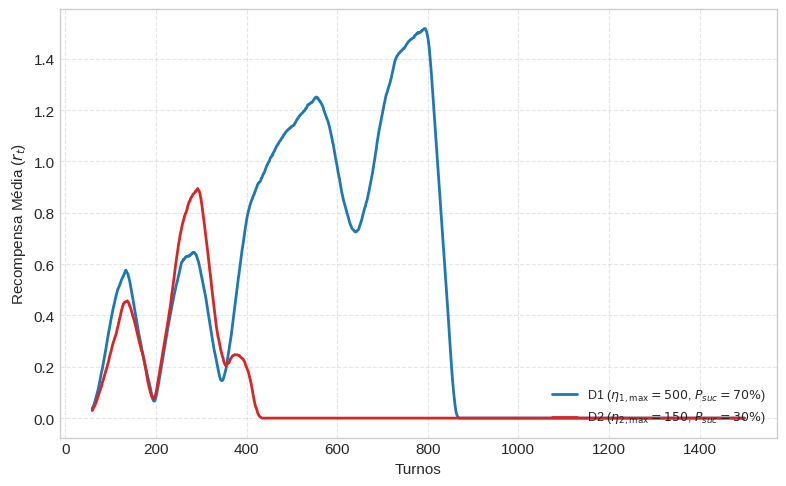

Salvos: cenario1_dominancia_alpha.svg, cenario1_dominancia_reward.svg, cenario1_dominancia_hist.svg
Iniciando cenário: cenario2_critico.svg...


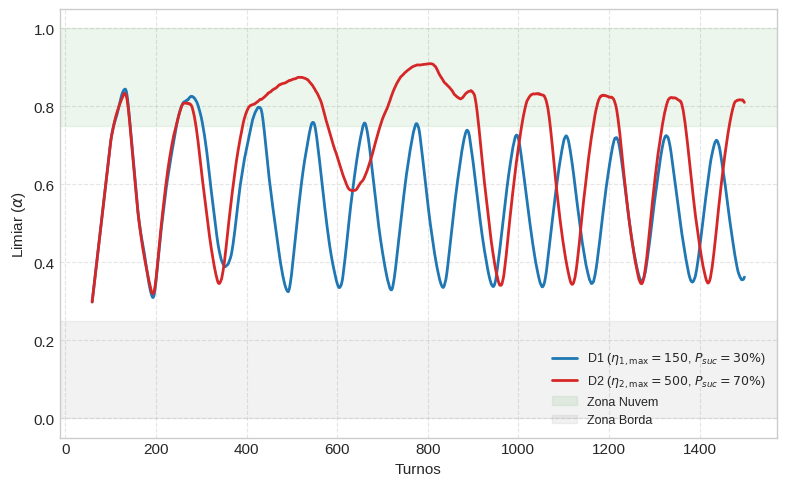

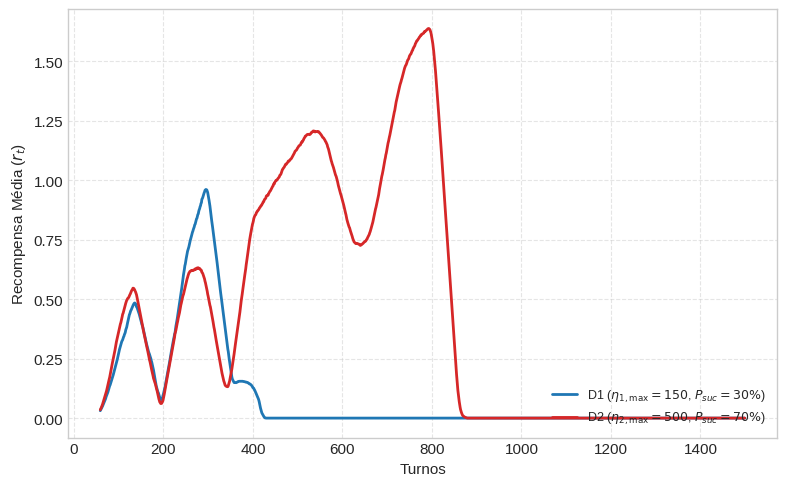

Salvos: cenario2_critico_alpha.svg, cenario2_critico_reward.svg, cenario2_critico_hist.svg
Iniciando cenário: cenario3_hardware_vs_rede.svg...


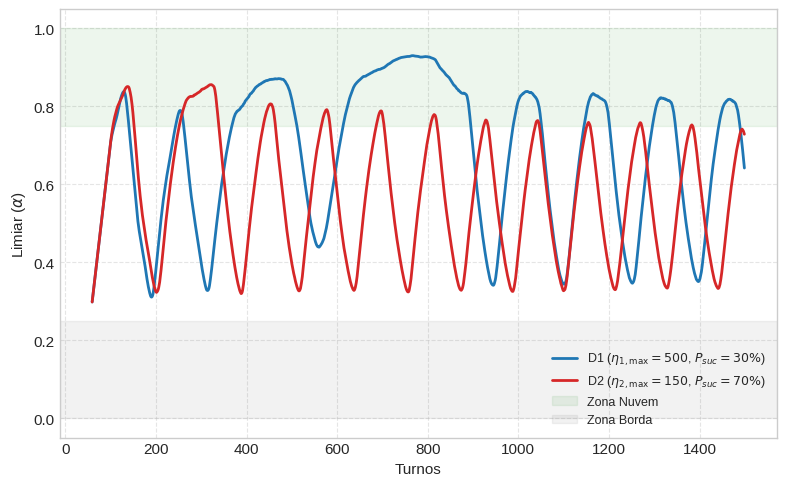

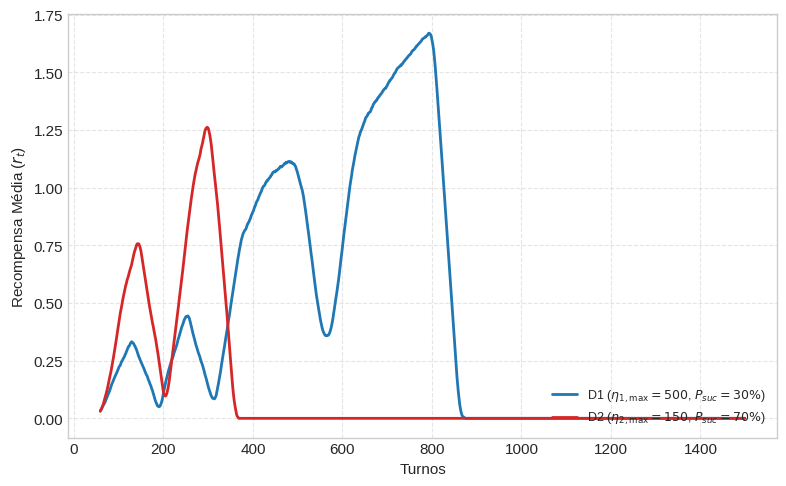

Salvos: cenario3_hardware_vs_rede_alpha.svg, cenario3_hardware_vs_rede_reward.svg, cenario3_hardware_vs_rede_hist.svg
Iniciando cenário: cenario4_rede_vs_hardware.svg...


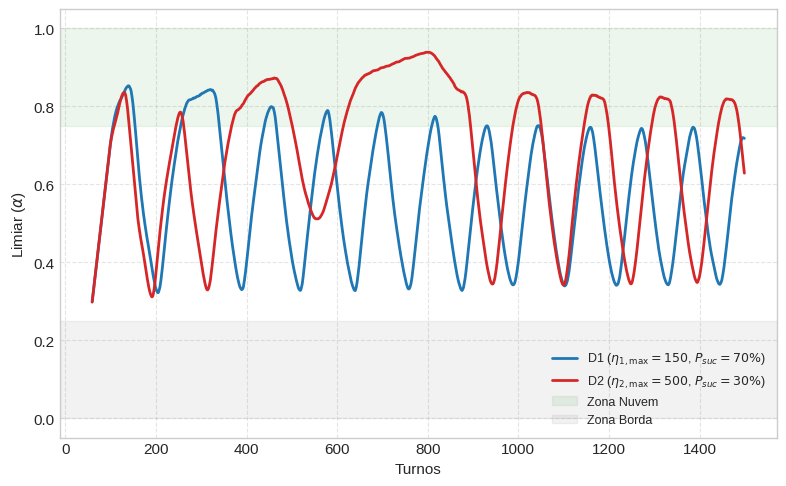

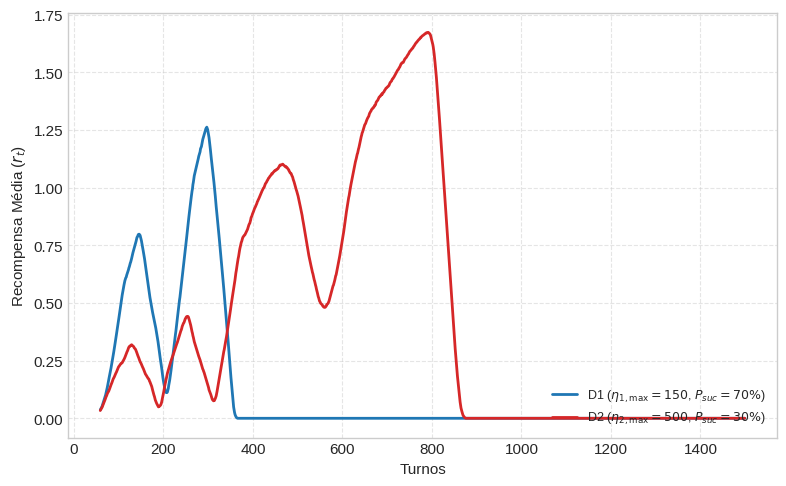

Salvos: cenario4_rede_vs_hardware_alpha.svg, cenario4_rede_vs_hardware_reward.svg, cenario4_rede_vs_hardware_hist.svg


In [32]:
if __name__ == "__main__":

    # D1 com dominancia energetica e de acesso aos recursos de servidor
    rodar_cenario(
        "cenario1_dominancia.svg",
        "",
        (BAT_100, PROB_70),
        (BAT_30, PROB_30)
    )

    # 2. D1 sem dominancia energetica e acesso a recursos de servidor
    rodar_cenario(
        "cenario2_critico.svg",
        "",
        (BAT_30, PROB_30),
        (BAT_100, PROB_70)
    )

    # 3. D1 com recursos energeticos e sem prioridade de acesso ao servidor
    rodar_cenario(
        "cenario3_hardware_vs_rede.svg",
        "",
        (BAT_100, PROB_30),
        (BAT_30, PROB_70)
    )

    # 4. D1 sem vantagem energetica e com prioridade no servidor
    rodar_cenario(
        "cenario4_rede_vs_hardware.svg",
        "",
        (BAT_30, PROB_70),
        (BAT_100, PROB_30)
    )